In [2]:
import pandas as pd
import numpy as np

# Fixer le seed pour que ton équipe ait les mêmes données de départ
np.random.seed(42)

# Génération d'une série temporelle hebdomadaire de Janvier 2020 à Décembre 2025
dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="W")
n = len(dates)

# 1. Tendance de fond : Croissance progressive des structures de santé au Togo
base_demand = np.linspace(1000, 1350, n)

# 2. Saisonnalité Paludisme & Grandes Vacances (Pic Mai-Septembre au Togo)
months = dates.month
malaria_season = np.sin((months - 5) * (np.pi / 6)) 
malaria_season = np.where(malaria_season > 0, malaria_season * 240, 0) 

# 3. Simulation des Accidents (Base DSR Togo : ~135 cas/semaine)
# Augmentation pendant les fêtes (décembre) et les départs de vacances (août)
base_accidents = 135 + 25 * np.sin((months - 11) * (np.pi / 6))
# Ajout d'un bruit de Poisson pour simuler des événements discrets (accidents réels)
accidents = base_accidents + np.random.poisson(15, n)

# Impact direct des accidents sur les urgences transfusions (multiplicateur)
accident_impact = accidents * 2.3

# 4. Chirurgies programmées (Stables avec légères vagues et bruit)
surgeries = 380 + 40 * np.sin((months - 3) * (np.pi / 6)) + np.random.normal(0, 15, n)

# 5. Météo ANAMET (Précipitations - Saison des pluies mai-juin / octobre)
rainy_score = (np.sin((months - 4) * (np.pi / 3)) + 1) * 3 + np.random.uniform(0, 2, n)
rainy_score = np.clip(rainy_score, 0, 7)

# 6. VARIABLE CIBLE : Demande finale de poches avec AJOUT DE BRUIT COMPLEXE
# Le bruit empêche le modèle de deviner la formule mathématique linéaire
noise = np.random.normal(0, 50, n) + np.random.uniform(-40, 40, n)
total_demand = base_demand + malaria_season + accident_impact + (surgeries * 0.7) + noise
total_demand = total_demand.astype(int)

# Création du Dataset final pour le Hackathon
df_togo = pd.DataFrame({
    'date': dates,
    'cas_accidents_reglementaires': accidents.astype(int),
    'chirurgies_programmees': surgeries.astype(int),
    'score_pluviometrie_anamet': np.round(rainy_score, 1),
    'demande_poches_sang': total_demand
})

# Sauvegarde du fichier
df_togo.to_csv('time_series_sang_togo_2020_2025.csv', index=False)
print("✅ Dataset temporel Togo (2020-2025) généré avec succès ! (313 semaines)")
print(df_togo.head())


✅ Dataset temporel Togo (2020-2025) généré avec succès ! (313 semaines)
        date  cas_accidents_reglementaires  chirurgies_programmees  \
0 2020-01-05                           174                     319   
1 2020-01-12                           166                     368   
2 2020-01-19                           172                     342   
3 2020-01-26                           175                     338   
4 2020-02-02                           171                     344   

   score_pluviometrie_anamet  demande_poches_sang  
0                        3.8                 1619  
1                        4.3                 1605  
2                        3.8                 1632  
3                        3.5                 1743  
4                        2.4                 1655  


In [3]:
data = pd.read_csv("togo.csv")
data.head()

,date,cas_accidents_reglementaires,chirurgies_programmees,score_pluviometrie_anamet,demande_poches_sang
0,2020-01-05,174,319,3.8,1619
1,2020-01-12,166,368,4.3,1605
2,2020-01-19,172,342,3.8,1632
3,2020-01-26,175,338,3.5,1743
4,2020-02-02,171,344,2.4,1655


In [8]:
import matplotlib.pyplot as plt  
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

# 1. Configuration temporelle (Base hebdomadaire Togo 2020-2025)
dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="W")
n = len(dates)

# 2. Distribution statistique des Groupes Sanguins au Togo
groupes = {
    'O_plus': 0.48, 'A_plus': 0.26, 'B_plus': 0.16, 'AB_plus': 0.05,
    'O_moins': 0.03, 'A_moins': 0.015, 'B_moins': 0.004, 'AB_moins': 0.001
}

data_rows = []

for idx, date in enumerate(dates):
    month = date.month
    
    # --- FLUX LOGISTIQUE GLOBAL (Tendance CNTS Togo) ---
    # Baisse saisonnière des dons pendant les grandes vacances (Août) et Noël
    facteur_mobilisation = 1.0
    if month in [8, 12]:
        facteur_mobilisation = 0.75  # Moins de donneurs disponibles
        
    # Le paludisme (Mai-Septembre) fait exploser les demandes de CGR
    facteur_palu = 1.35 if month in [5, 6, 7, 8, 9] else 1.0

    # Collectes planifiées (Campagnes mobiles du CNTS à Lomé, Kpalimé, Kara...)
    collectes_prevues = int(12 + 4 * np.sin(idx * 0.1) + np.random.poisson(2))
    poches_collectees_total = int((collectes_prevues * 85) * facteur_mobilisation + np.random.normal(0, 50))
    
    # --- VENTILATION PAR GROUPE SANGUIN & COMPOSANT ---
    for grp, prop in groupes.items():
        # Dons reçus pour ce groupe précis
        dons_grp = int(poches_collectees_total * prop)
        
        # Séparation biologique : 1 don = 1 CGR + 1 Plasma + (parfois) Plaquettes
        collecte_CGR = dons_grp
        collecte_Plasma = int(dons_grp * 0.95)
        collecte_Plaquettes = int(dons_grp * 0.25) # Moins fréquent
        
        # Demande de base des hôpitaux togolais pour ce groupe
        demande_base = int((1150 * prop) * facteur_palu + np.random.normal(0, 15))
        
        # Urgences imprévisibles (Accidents de la route sur la Nationale 1, accouchements complexes)
        urgences_accidents = int(np.random.poisson(8) if grp in ['O_plus', 'A_plus', 'O_moins'] else np.random.poisson(1))
        
        demande_CGR = int(demande_base * 1.1 + urgences_accidents)
        demande_Plasma = int(demande_base * 0.4)
        demande_Plaquettes = int(demande_base * 0.15)
        
        # Simulation du Stock initial en réserve (jour J) - Sujet à de fortes tensions sur les Rhésus -
        stock_secu_coef = 6 if grp in ['O_plus', 'A_plus'] else 2 # Moins de réserve sur les groupes rares
        stock_J_CGR = int(demande_CGR * stock_secu_coef + np.random.uniform(-40, 40))
        stock_J_Plasma = int(demande_Plasma * 15 + np.random.uniform(-20, 100)) # Se conserve mieux
        stock_J_Plaquettes = int(demande_Plaquettes * 1.5 + np.random.uniform(-5, 10)) # Périme vite (7 jours)
        
        # Sécurisation anti-négatif
        stock_J_CGR = max(5, stock_J_CGR)
        stock_J_Plasma = max(10, stock_J_Plasma)
        stock_J_Plaquettes = max(2, stock_J_Plaquettes)

        # --- CALCUL DE LA VARIABLE CIBLE : PÉSURIE À J+7 ---
        # Si la demande dépasse le stock + les collectes de la semaine -> Rupture/Pénurie
        balance_CGR = (stock_J_CGR + collecte_CGR) - demande_CGR
        
        # Label de pénurie (0 = Stable, 1 = Flux tendu, 2 = Pénurie Critique)
        if balance_CGR < 10:
            statut_penurie_J7 = 2
        elif balance_CGR < 35:
            statut_penurie_J7 = 1
        else:
            statut_penurie_J7 = 0
            
        # Injection du bruit final sur la balance pour casser le déterminisme mathématique
        if np.random.rand() > 0.92: 
            statut_penurie_J7 = np.random.choice([0, 1, 2]) # Erreur humaine ou bug logistique simulé

        data_rows.append({
            'date': date,
            'groupe_sanguin': grp,
            'campagnes_collecte_prevues': collectes_prevues,
            'dons_poches_collectees': dons_grp,
            'stock_initial_CGR': stock_J_CGR,
            'stock_initial_Plasma': stock_J_Plasma,
            'stock_initial_Plaquettes': stock_J_Plaquettes,
            'prev_demande_CGR_hopitaux': demande_CGR,
            'prev_demande_Plasma_hopitaux': demande_Plasma,
            'prev_demande_Plaquettes_hopitaux': demande_Plaquettes,
            'cible_penurie_J7': statut_penurie_J7
        })

# Construction du DataFrame
df_cnts_togo = pd.DataFrame(data_rows)
df_cnts_togo.to_csv('dataset_complet_cnts_togo_2020_2025.csv', index=False)

print("🚀 Dataset expert CNTS Togo exporté : 'dataset_complet_cnts_togo_2020_2025.csv'")
print(f"Nombre de lignes générées : {len(df_cnts_togo)} (313 semaines x 8 groupes sanguins)")
print(df_cnts_togo.sample(3))


🚀 Dataset expert CNTS Togo exporté : 'dataset_complet_cnts_togo_2020_2025.csv'
Nombre de lignes générées : 2504 (313 semaines x 8 groupes sanguins)
          date groupe_sanguin  campagnes_collecte_prevues  \
62  2020-02-23        B_moins                          14   
752 2021-10-24         O_plus                          15   
802 2021-12-05         B_plus                          13   

     dons_poches_collectees  stock_initial_CGR  stock_initial_Plasma  \
62                        4                  9                    48   
752                     598               3772                  3360   
802                     132                370                  1083   

     stock_initial_Plaquettes  prev_demande_CGR_hopitaux  \
62                          2                         -1   
752                       125                        629   
802                        44                        200   

     prev_demande_Plasma_hopitaux  prev_demande_Plaquettes_hopitaux  \
62    

In [5]:
data =pd.read_csv("tgo.csv")

In [6]:
data.head()

,date,groupe_sanguin,campagnes_collecte_prevues,dons_poches_collectees,stock_initial_CGR,stock_initial_Plasma,stock_initial_Plaquettes,prev_demande_CGR_hopitaux,prev_demande_Plasma_hopitaux,prev_demande_Plaquettes_hopitaux,cible_penurie_J7
0,2020-01-05,O_plus,16,659,3758,3432,128,629,226,85,0
1,2020-01-05,A_plus,16,356,1916,1695,58,318,113,42,1
2,2020-01-05,B_plus,16,219,381,1187,43,207,75,28,0
3,2020-01-05,AB_plus,16,68,121,302,13,54,19,7,0
4,2020-01-05,O_moins,16,41,78,221,6,46,13,5,0


In [7]:
data.shape

(2504, 11)

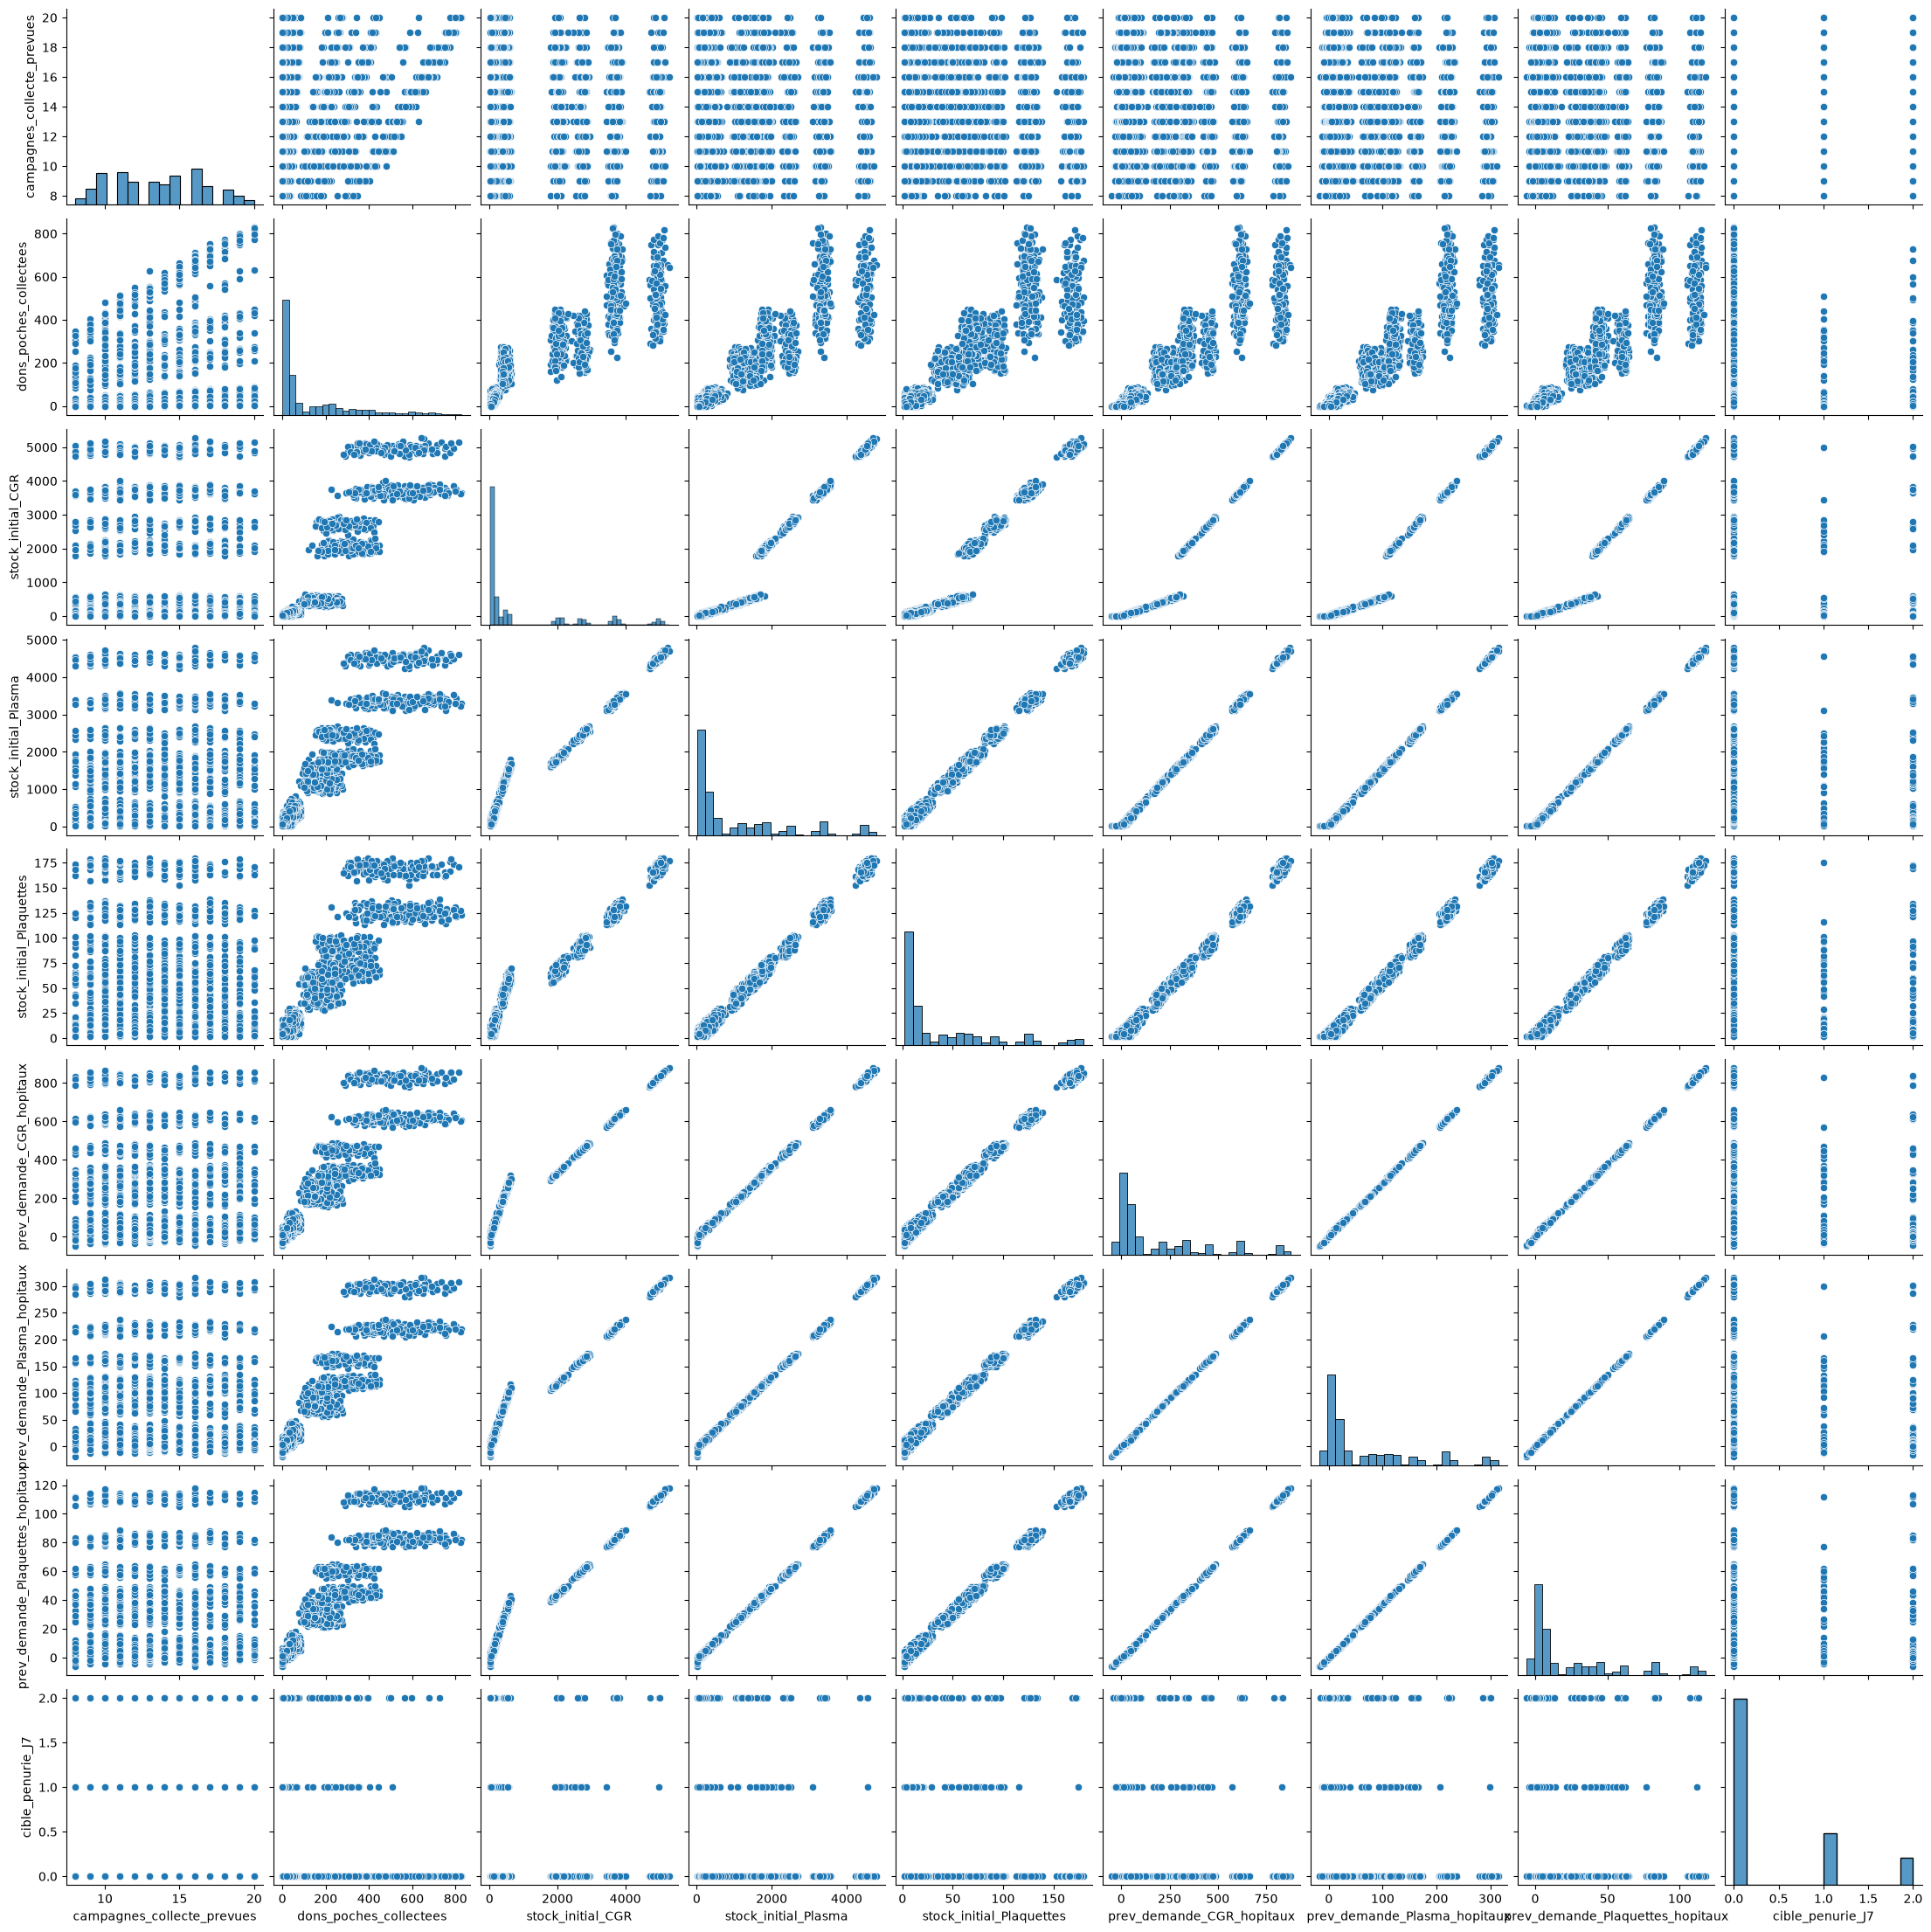

In [9]:
sns.pairplot(data)

<Axes: >

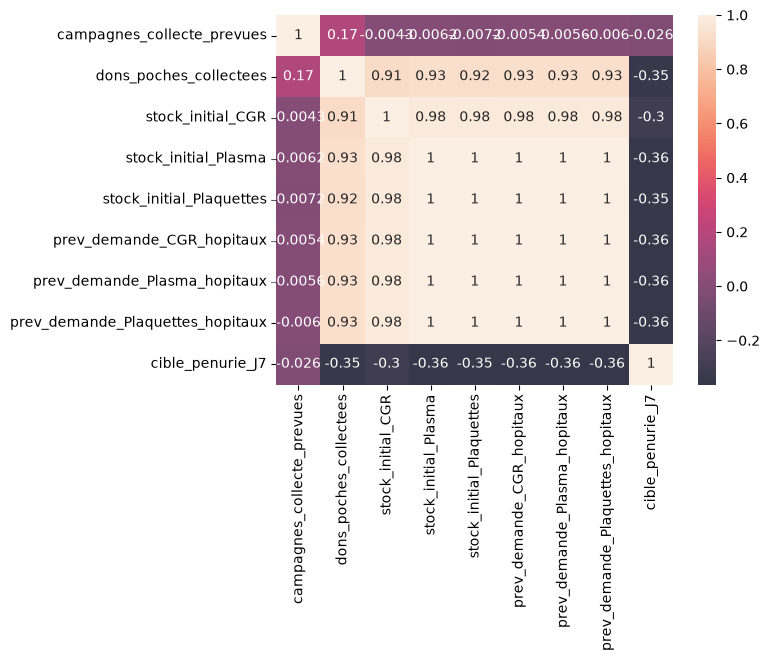

In [10]:
sns.heatmap(data.corr(numeric_only = True), annot = True , alpha= 0.8)

In [11]:
df = pd.read_csv("Data_Sheet_1.csv")

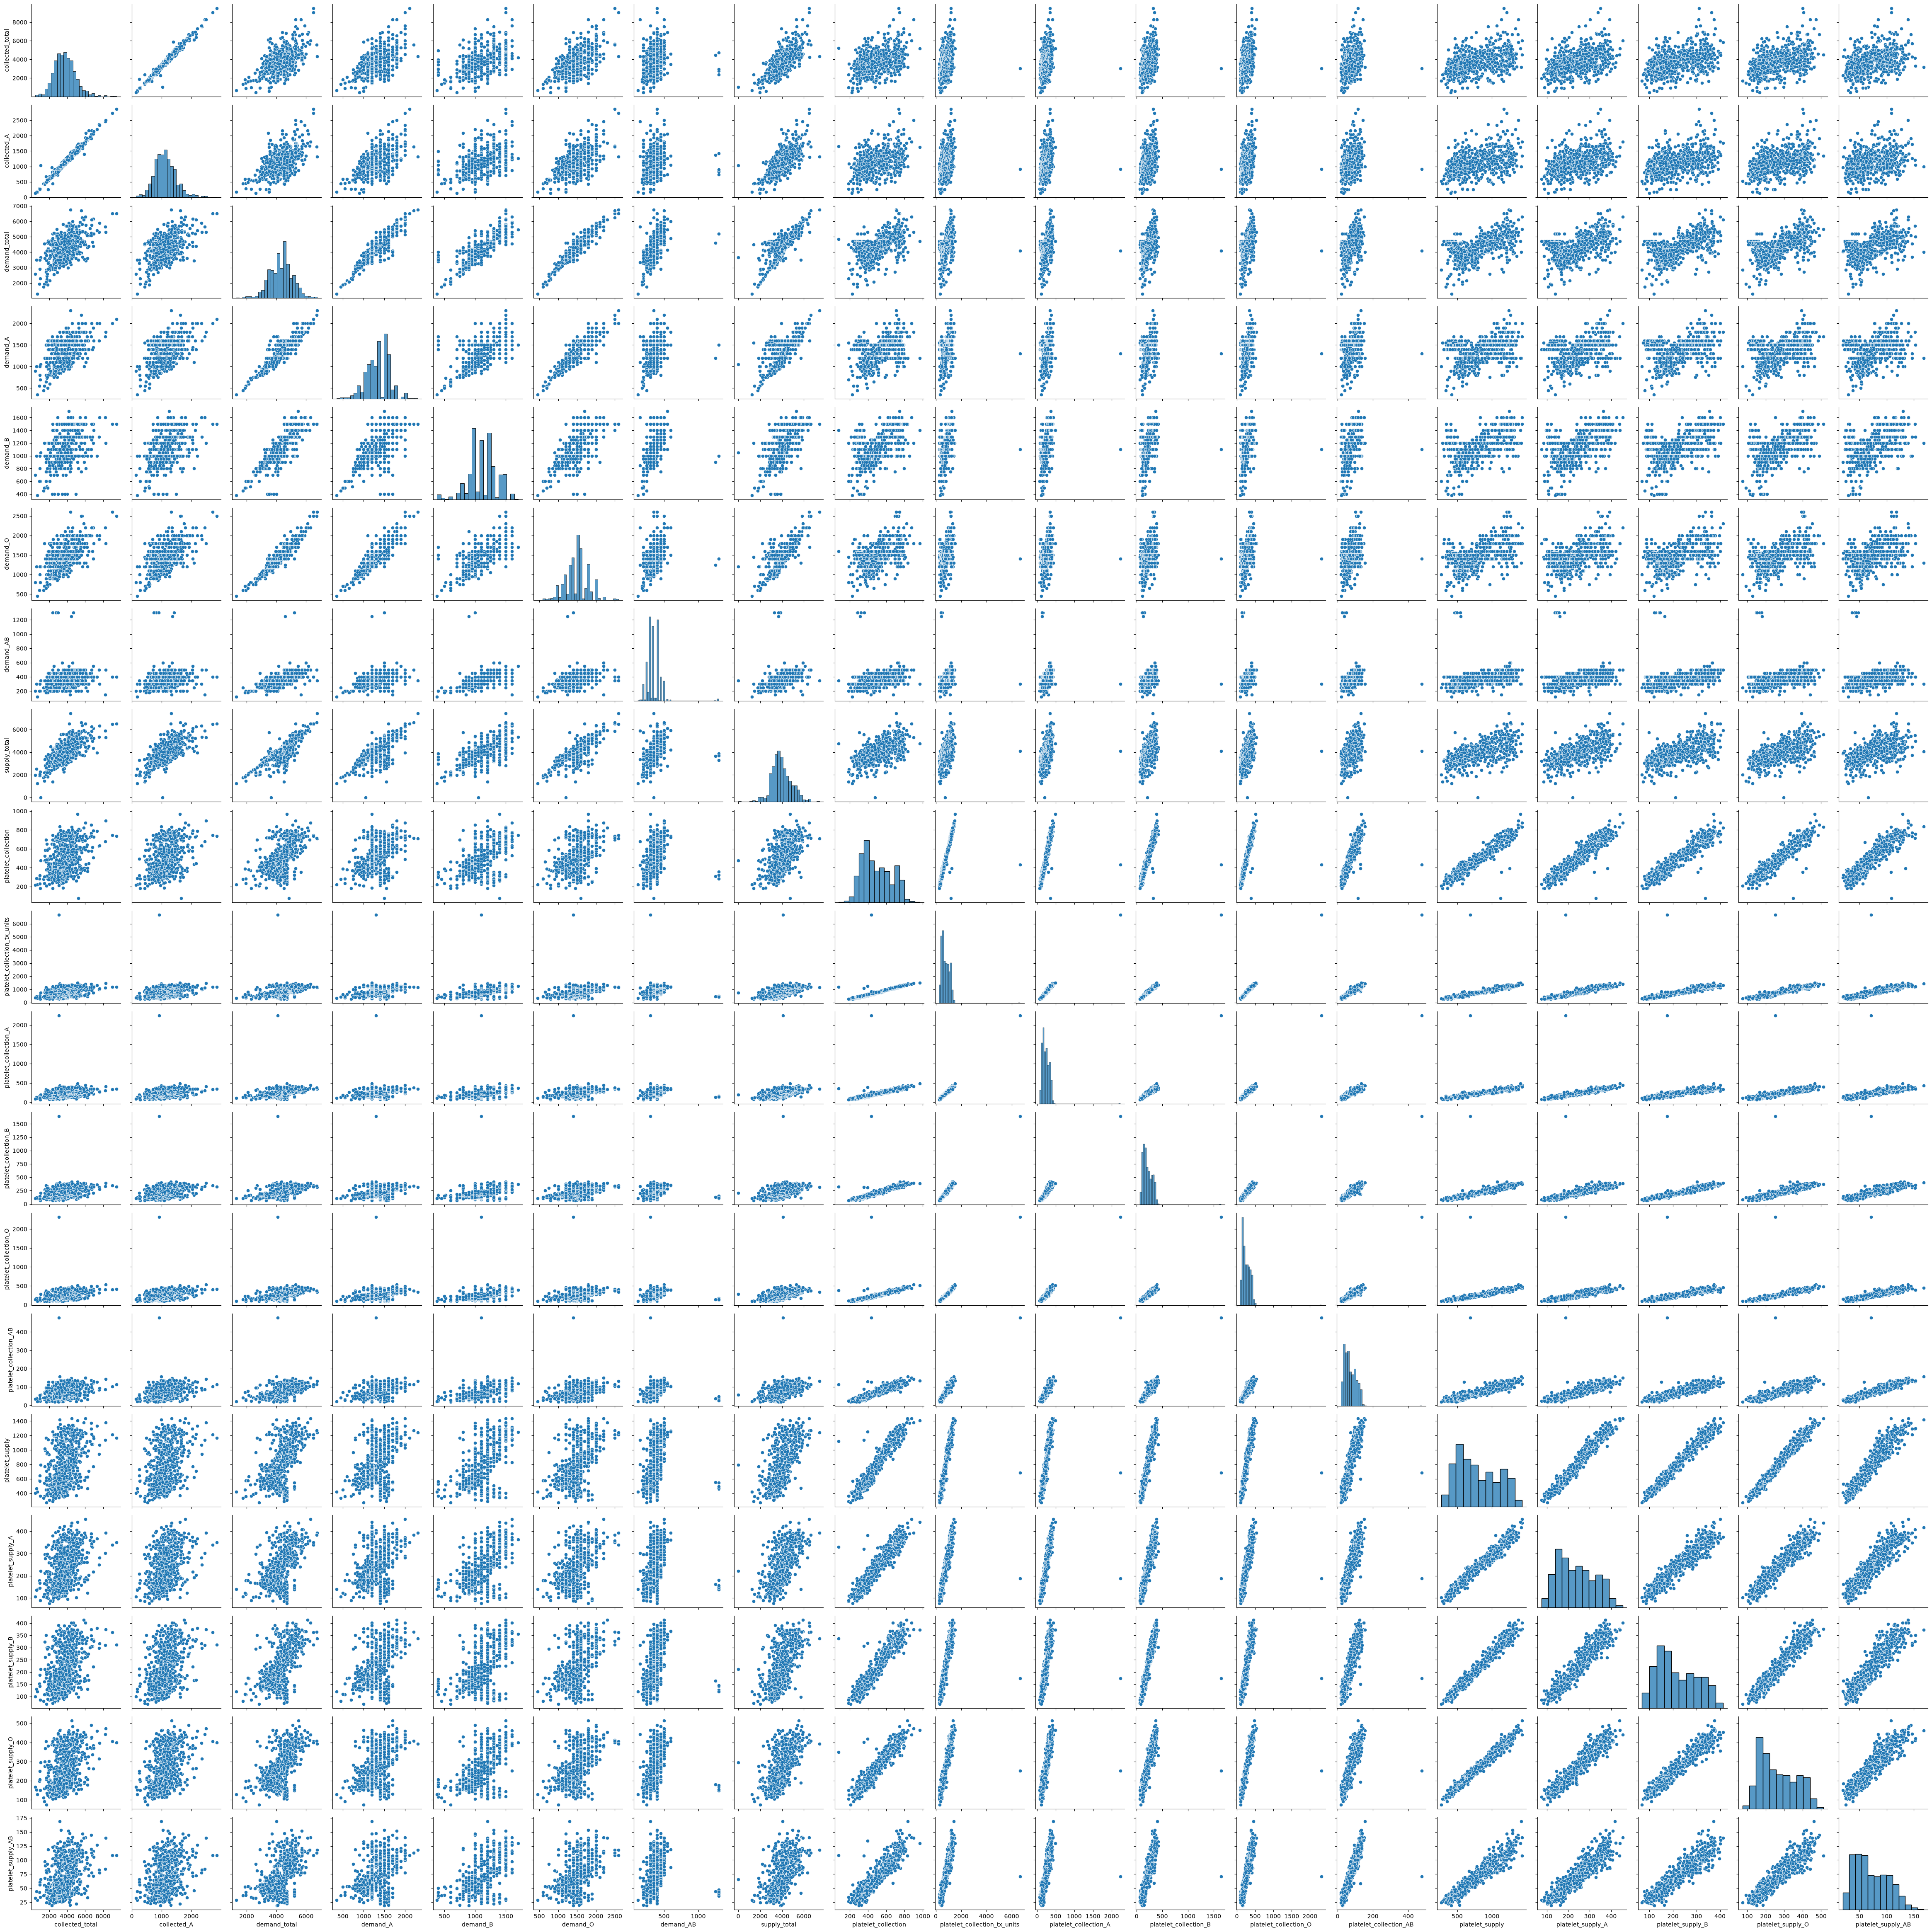

In [12]:
sns.pairplot(df)

<Axes: >

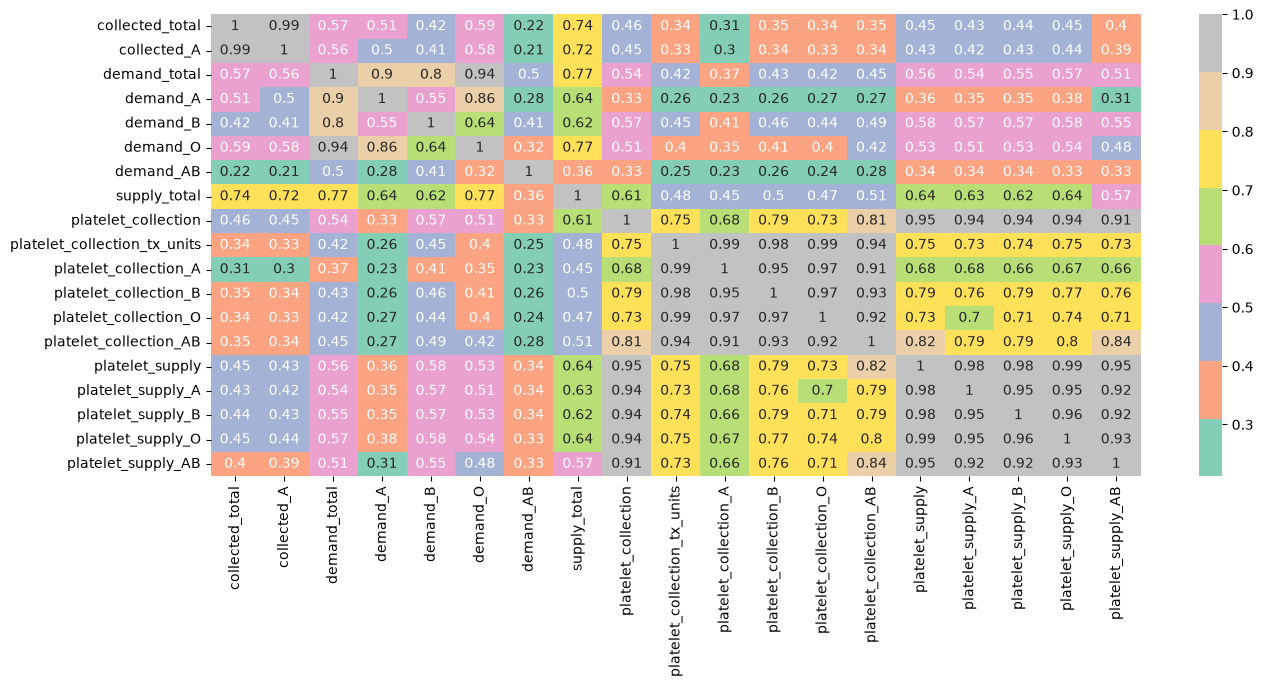

In [16]:
plt.figure(figsize= (15,6))
sns.heatmap(df.corr(numeric_only= True), annot =True, alpha = 0.8, cmap = "Set2")